##1. Problem Statement

##Objective

The objective of this project is to segment customers into distinct groups based on their spending behavior and demographic characteristics using K-Means Clustering. The identified customer segments will help businesses develop targeted marketing strategies and improve customer engagement.

##Observation

Customer segmentation enables organizations to understand different customer groups and allocate marketing resources more effectively. Instead of treating all customers equally, businesses can create personalized campaigns for each segment

##2. Dataset Description and Loading

##Objective

To understand the structure, features, and overall characteristics of the Mall Customers dataset before performing any analysis.

##Dataset Features

| Feature                | Description                         |
| ---------------------- | ----------------------------------- |
| CustomerID             | Unique customer identifier          |
| Gender                 | Male/Female                         |
| Age                    | Customer age                        |
| Annual Income (k$)     | Annual income in thousand dollars   |
| Spending Score (1-100) | Spending score assigned by the mall |


In [9]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Observation

The dataset contains customer demographic and spending information that can be used to identify distinct customer groups.

##3. Data Exploration

##Objective

To examine the dataset dimensions, data types, and basic statistics.

In [10]:
df.shape

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


##Observation

The dataset contains numerical and categorical variables. Understanding these attributes helps determine appropriate preprocessing techniques before clustering.

##4. Data Cleaning and Preprocessing

##4.1 Missing Values

##Objective

To identify and handle any missing values that may affect clustering performance

In [11]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


## Observation

No missing values were found in the dataset, indicating that the dataset is clean and ready for analysis.

##4.2 Duplicate Records

## Objective

To check for duplicate customer records that may bias clustering results.

In [12]:
df.duplicated().sum()

np.int64(0)

##Observation

No significant duplicate records were detected.

##4.3 Encoding Categorical Variables

 ## Objective

To convert categorical variables into numerical form for machine learning algorithms.

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


## Observation

Gender values were successfully converted into numerical format, making them suitable for clustering analysis.

##4.4 Feature Selection

## Objective

To normalize feature values so that all variables contribute equally during clustering.

In [17]:
from sklearn.preprocessing import StandardScaler

# Select the features for clustering
X = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Observation

Feature scaling ensures that variables with larger numerical ranges do not dominate the clustering process.

##5. Exploratory Data Analysis (EDA)

## Objective

To analyze customer distribution across genders.

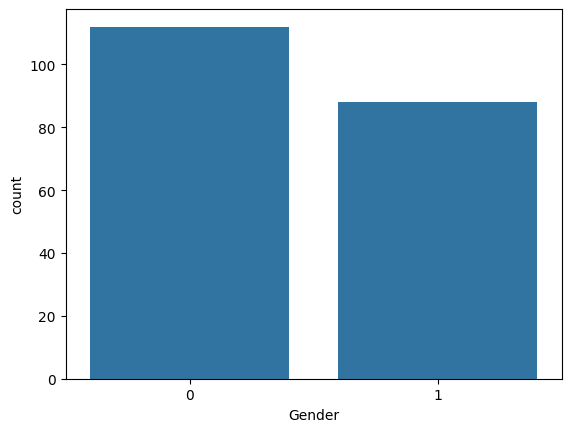

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Gender', data=df)
plt.show()

##Observation

The dataset contains customers from both genders, providing balanced demographic representation.

##5.2 Age Distribution

##Objective

To understand the age distribution of customers.

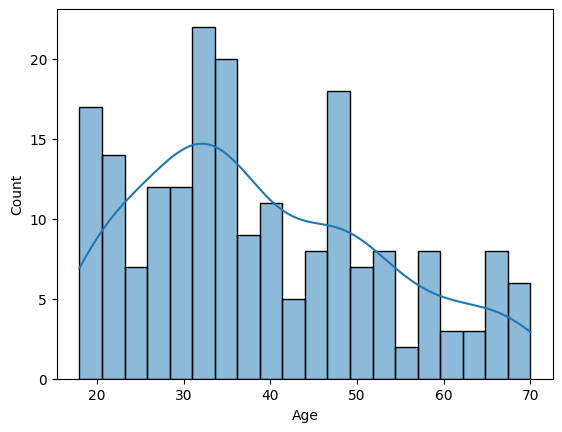

In [19]:
sns.histplot(df['Age'], bins=20, kde=True)
plt.show()

##Observstion

Most customers fall within the young to middle-aged category, suggesting that the mall attracts a relatively active consumer population.

##5.3 Income Distribution

## Objective

To examine variations in customer income levels.

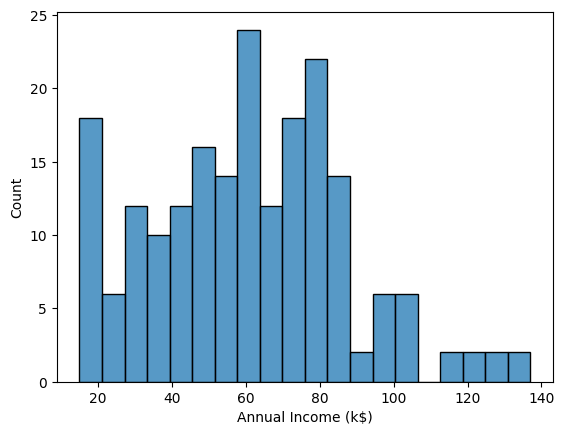

In [20]:
sns.histplot(df['Annual Income (k$)'], bins=20)
plt.show()

##Observation

Customers exhibit a wide range of income levels, indicating diverse purchasing capabilities.

##5.4 Spending Score Distribution

##Objective

To evaluate customer spending behavior.

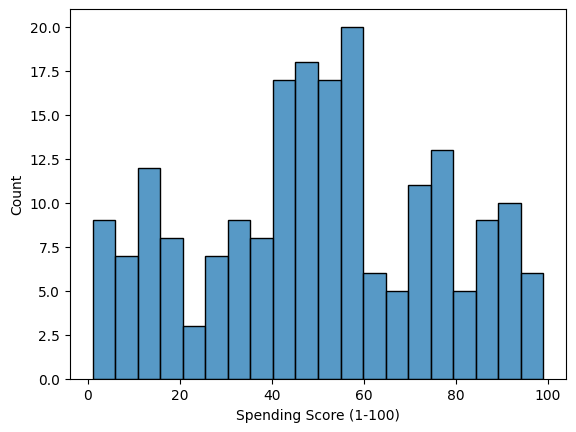

In [21]:
sns.histplot(df['Spending Score (1-100)'], bins=20)
plt.show()

##Observation

Spending scores vary significantly among customers, suggesting the presence of multiple customer segments.

##5.5 Correlation Analysis

##Objective

To identify relationships among numerical variables.

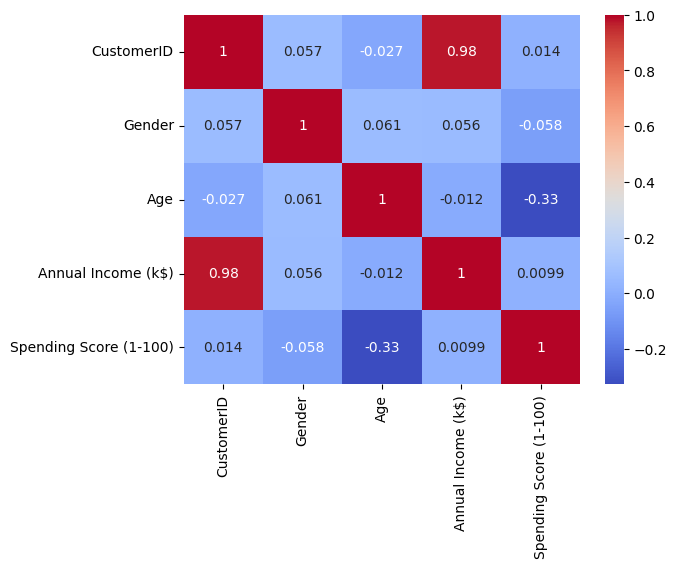

In [22]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.show()

##Observation

The correlation matrix provides insights into how customer attributes relate to spending behavior and income levels.

##6. K-Means Clustering

##6.1 Finding Optimal Number of Clusters (Elbow Method)

##Objective

To determine the optimal number of customer segment

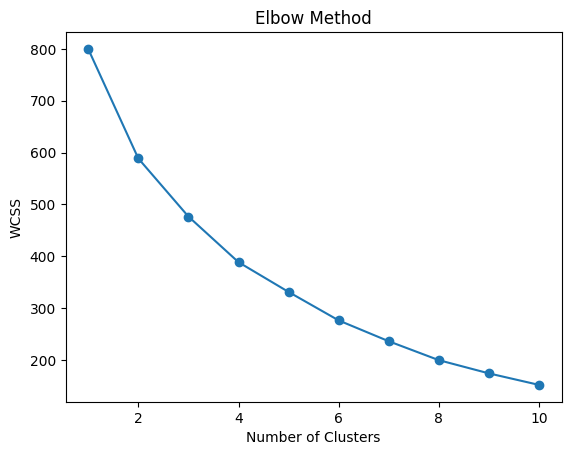

In [23]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,
                    random_state=42,
                    n_init=10)

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

##Observation

The elbow point appears around 5 clusters, indicating that five customer segments may provide the best balance between simplicity and cluster quality.

##6.2 Training K-Means Model

##Objective

To group customers into meaningful clusters based on spending behavior.

In [24]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

##Observation

Customers were successfully assigned to five distinct clusters based on similarities in age, income, and spending score.

##7. Cluster Visualization using PCA

##Observation

To reduce dimensionality and visualize customer segments in a two-dimensional space.

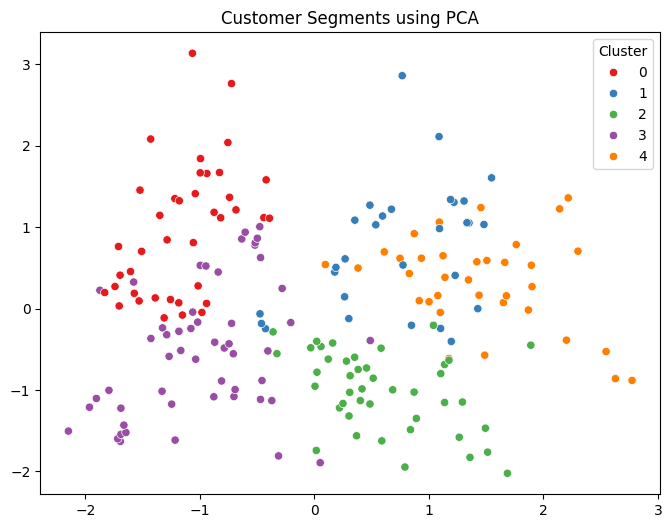

In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Customer Segments using PCA")
plt.show()

##Observation

The PCA visualization shows clear separation between customer groups, indicating that K-Means successfully identified meaningful segments.

##8. Marketing Strategy Recommendations

##Objective

To develop business strategies based on identified customer segment

##Observation & Strategy

| Cluster   | Characteristics            | Marketing Strategy                    |
| --------- | -------------------------- | ------------------------------------- |
| Cluster 0 | High Income, High Spending | Premium memberships, exclusive offers |
| Cluster 1 | High Income, Low Spending  | Personalized promotions               |
| Cluster 2 | Low Income, High Spending  | Discount loyalty programs             |
| Cluster 3 | Low Income, Low Spending   | Budget-friendly campaigns             |
| Cluster 4 | Average Income & Spending  | Regular engagement campaigns          |


##9.Final Conlclusion

Five distinct customer segments were identified using K-Means clustering. The segmentation revealed differences in income levels, spending habits, and customer behavior. PCA visualization confirmed effective cluster separation. These insights can help businesses design targeted marketing strategies, improve customer satisfaction, and maximize revenue through personalized engagement.